# PSHA from scratch

**Geotechnical Hazards** · tutorial for Lectures 10 and 11

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pstafford/geohazards-psha/blob/main/notebooks/01_psha_from_scratch.ipynb)

This notebook carries out a complete probabilistic seismic hazard analysis (PSHA) for the toy model
used in the lectures: a site near a fault and inside an area source. Every step is a few lines of
`numpy`, and the whole calculation is in `psha_toy.py` (about 250 lines). The companion notebook
repeats it with **OpenQuake**, the hazard software used for national and global models, and gets
the same answers.

**You do not need to know Python.** Run the cells in order (Shift + Enter, or *Runtime → Run all*
on Colab). Numbers you are invited to change are marked ✏️. This is a tutorial, not an assignment:
the aim is to build intuition, so change things and see what happens. The
[PSHA Explorer](https://pstafford.github.io/geohazards-psha/) does the same calculation in a web page.

**Contents**
1. The model
2. Magnitude–frequency distributions
3. A first hazard calculation: one source at one distance
4. Every rupture scenario
5. Ground motions
6. The hazard curve: a sum over scenarios
7. Uniform hazard spectrum
8. Disaggregation
9. Conditional mean spectrum
10. Sensitivity analyses
11. Saving results

In [1]:
# Setup. On Colab this downloads the course code; on your own computer it uses the repository.
import os, sys, subprocess
if "google.colab" in sys.modules:
    if not os.path.exists("geohazards-psha"):
        subprocess.run(["git", "clone", "-q", "https://github.com/pstafford/geohazards-psha"], check=True)
    sys.path.insert(0, "geohazards-psha/psha")
else:
    sys.path.insert(0, os.path.abspath("../psha"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psha_toy as pt

plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.3, "font.size": 12})
FAULT_C, AREA_C = "#D24000", "#0000CD"     # the colours used in the lectures
P = pt.PARAMS                               # the model's parameters

## 1. The model

A site on rock ($V_{S30}$ = 760 m/s) at the origin, and two sources:

* a **fault**: vertical, strike-slip, 115 km long, 50 km north of the site, rupturing 0–18 km depth;
  characteristic magnitude–frequency distribution (Youngs & Coppersmith, 1985), activity from a slip rate;
* an **area source**: a circle of radius 70 km around the site, earthquakes at 9 km depth;
  truncated Gutenberg–Richter distribution.

Ground motions come from Chiou & Youngs (2014), truncated at $\pm 3\sigma$. All parameters are in one
dictionary (distances in km, slip rate in mm/yr, rates per year):

In [2]:
pd.DataFrame({"value": [f"{v:g}" for v in P.values()]}, index=list(P))

,value
vs30,760
fault_dist,50
fault_left,35
fault_right,80
fault_top,0
fault_bottom,18
fault_mmin,5
fault_b,1.2
fault_mchar,7.45
fault_slip_rate,30


## 2. Magnitude–frequency distributions

### Area source: truncated Gutenberg–Richter

The rate of earthquakes with magnitude at least $m$, between $m_{min}$ and $m_{max}$, is

$$\lambda(M \geq m) = \lambda(M \geq m_{min})\,\frac{10^{-bm} - 10^{-b m_{max}}}{10^{-b m_{min}} - 10^{-b m_{max}}}$$

We work with magnitude bins of width 0.1 (centres 5.05, 5.15, …); the rate in a bin is the
difference of $\lambda(M \geq m)$ at its edges.

In [3]:
def gr_rates(mmin, mmax, b, rate, dm):
    n = round((mmax - mmin) / dm)
    m = mmin + dm * (np.arange(n) + 0.5)                      # bin centres
    N = lambda x: rate * (10**(-b * x) - 10**(-b * mmax)) / (10**(-b * mmin) - 10**(-b * mmax))
    return m, N(m - dm / 2) - N(m + dm / 2)                   # rate in each bin

m_area, rate_area = gr_rates(P["area_mmin"], P["area_mmax"], P["area_b"], P["area_rate"], P["dm"])
print(f"{len(m_area)} bins, total rate {rate_area.sum():.3f} per year")
print("same as psha_toy:", np.allclose(rate_area, pt.gr_rates(P["area_mmin"], P["area_mmax"], P["area_b"], P["area_rate"], P["dm"])[1]))

15 bins, total rate 0.500 per year
same as psha_toy: True


### Fault: characteristic distribution, balanced against the slip rate

Youngs & Coppersmith (1985): an exponential (Gutenberg–Richter) part for smaller events, plus a
"box" of characteristic events within $\pm 0.25$ of $m_{char}$. Its overall rate comes from
**moment balance**: the earthquakes must release the seismic moment accumulated by the slip,
$\dot{M}_0 = \mu A \dot{s}$, with $M_0 = 10^{1.5M + 9.05}$ N m.

In [4]:
def yc85_shape(mmin, b, mchar, dm):
    n = round((mchar + 0.25 - mmin) / dm)
    m = mmin + dm * (np.arange(n) + 0.5)
    expo = 10**(-b * (m - dm / 2)) - 10**(-b * (m + dm / 2))       # exponential part
    box = b * np.log(10) * 10**(-b * (mchar - 1.25)) * dm         # characteristic box
    return m, np.where(m < mchar - 0.25, expo, box)

m_fault, shape = yc85_shape(P["fault_mmin"], P["fault_b"], P["fault_mchar"], P["dm"])
area = (P["fault_left"] + P["fault_right"]) * (P["fault_bottom"] - P["fault_top"]) * 1e6   # m^2
moment_rate = P["shear_modulus"] * area * P["fault_slip_rate"] / 1000                     # N m per year
rate_fault = shape * moment_rate / np.sum(shape * pt.moment(m_fault))

char = m_fault > P["fault_mchar"] - 0.25
print(f"fault: rate of M >= 5 = {rate_fault.sum():.3f}/yr; characteristic events {rate_fault[char].sum():.4f}/yr "
      f"(one every {1 / rate_fault[char].sum():.0f} years)")
print("same as psha_toy:", np.allclose(rate_fault, pt.fault_mfd()[1]))

fault: rate of M >= 5 = 0.215/yr; characteristic events 0.0103/yr (one every 97 years)
same as psha_toy: True


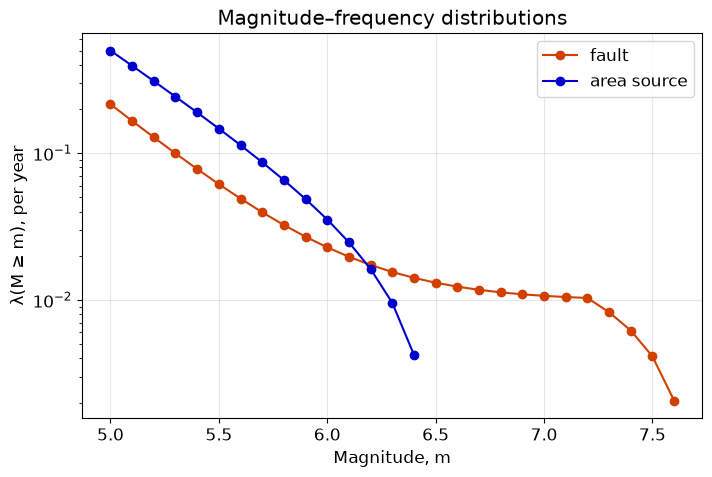

In [5]:
fig, ax = plt.subplots()
for m, r, col, name in ((m_fault, rate_fault, FAULT_C, "fault"), (m_area, rate_area, AREA_C, "area source")):
    cumulative = np.cumsum(r[::-1])[::-1]                    # lambda(M >= lower edge of each bin)
    ax.semilogy(m - P["dm"] / 2, cumulative, "o-", color=col, label=name)
ax.set(xlabel="Magnitude, m", ylabel="λ(M ≥ m), per year", title="Magnitude–frequency distributions")
ax.legend();

## 3. A first hazard calculation: one source at one distance

Before the full model, the simplest case: every area-source earthquake happens at the same place,
15 km from the site. The hazard is a sum over magnitudes,

$$\lambda(IM > im) = \sum_{j} P(IM > im \mid m_j, r)\;\lambda(M = m_j)$$

where $P(IM > im \mid m, r)$ comes from the ground-motion model: $\ln IM$ is normally distributed
with mean `mean` and standard deviation `sigma` (truncated at $\pm 3\sigma$).

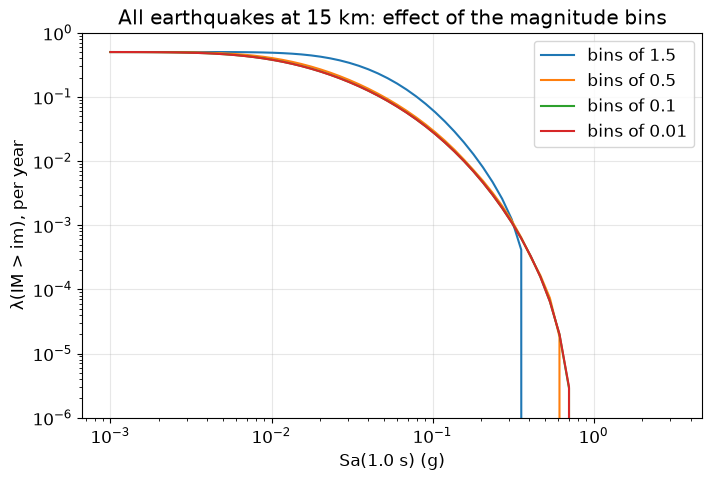

In [6]:
T = 1.0                                     # ✏️ period (s); 0 means PGA
imls = np.logspace(-3, 0.5, 60)             # levels of ground motion, 0.001 to 3 g
rjb, depth = 15.0, P["area_depth"]          # ✏️ epicentral distance (km)
rrup = np.hypot(rjb, depth)

def one_distance_hazard(m, rates):
    mean, sigma = pt.cy14(T, m, np.full_like(m, rrup), np.full_like(m, rjb), np.full_like(m, depth), P["vs30"])
    return np.array([np.sum(rates * pt.prob_exceed(x, mean, sigma)) for x in imls])

fig, ax = plt.subplots()
for dm in (1.5, 0.5, 0.1, 0.01):            # ✏️ the width of the magnitude bins (1.5 = one bin)
    m, r = gr_rates(P["area_mmin"], P["area_mmax"], P["area_b"], P["area_rate"], dm)
    ax.loglog(imls, one_distance_hazard(m, r), label=f"bins of {dm}")
ax.set(xlabel=f"Sa({T} s) (g)", ylabel="λ(IM > im), per year", ylim=(1e-6, 1),
       title=f"All earthquakes at {rjb:.0f} km: effect of the magnitude bins")
ax.legend();

✏️ *Try*: how coarse can the magnitude bins be before the curve changes? Does it matter more at
long return periods (small rates)? Why?

## 4. Every rupture scenario

In the real model the earthquakes can happen anywhere on the fault or in the area. Following
OpenQuake:

* **fault**: a rupture of magnitude $m$ has the area given by Wells & Coppersmith (1994), and it
  *floats* to every position along and down the fault (on a 1 km grid); the rate of magnitude $m$ is
  shared equally among the positions;
* **area source**: earthquakes are points on a 2 km grid, at 9 km depth; the rate is shared equally
  among the points.

`pt.scenarios()` lists every scenario once: source (0 = fault, 1 = area), magnitude, annual rate and
distances.

In [7]:
sc = pt.scenarios()
table = pd.DataFrame(sc)
print(f"{len(table):,} scenarios")
table.groupby("source").agg(scenarios=("rate", "size"), total_rate=("rate", "sum"),
                            closest_km=("rrup", "min"), farthest_km=("rrup", "max"))

78,479 scenarios


,scenarios,total_rate,closest_km,farthest_km
source,,,,
0.0,20864,0.21542,50.0,92.200868
1.0,57615,0.50000,9.0,70.547856


In [8]:
table.sample(8, random_state=1)                  # a few random rows of the table

,source,mag,rate,rjb,rrup,ztor,x0,x1
31603,1.0,5.25,0.000017,34.234486,35.397740,9.0,NaN,NaN
34215,1.0,5.35,0.000014,46.043458,46.914816,9.0,NaN,NaN
46915,1.0,5.65,0.000007,35.777088,36.891733,9.0,NaN,NaN
36736,1.0,5.45,0.000011,55.605755,56.329388,9.0,NaN,NaN
72483,1.0,6.35,0.000001,54.332311,55.072679,9.0,NaN,NaN
11086,0.0,5.65,0.000007,82.006097,82.613558,10.0,65.0,73.0
38465,1.0,5.45,0.000011,56.885851,57.593402,9.0,NaN,NaN
48106,1.0,5.75,0.000006,64.031242,64.660653,9.0,NaN,NaN


## 5. Ground motions

For each scenario, the Chiou & Youngs (2014) model gives the mean and standard deviation of
$\ln IM$. Below: the median and the $\pm 1\sigma$ band against distance, for three magnitudes.

M 7.45 at 50 km: median 0.055 g, sigma 0.68; 0.2 g is 1.90 standard deviations above the median: P(IM > 0.2 g) = 0.028


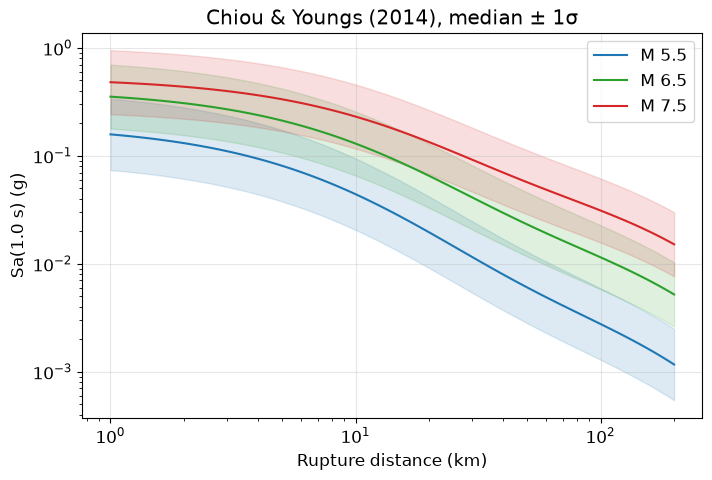

In [9]:
T = 1.0                                     # ✏️ period (s)
r = np.logspace(0, 2.3, 100)
fig, ax = plt.subplots()
for m, col in ((5.5, "C0"), (6.5, "C2"), (7.5, "C3")):
    mean, sigma = pt.cy14(T, np.full_like(r, m), r, r, np.zeros_like(r), P["vs30"])
    ax.loglog(r, np.exp(mean), color=col, label=f"M {m}")
    ax.fill_between(r, np.exp(mean - sigma), np.exp(mean + sigma), color=col, alpha=0.15)
ax.set(xlabel="Rupture distance (km)", ylabel=f"Sa({T} s) (g)", title="Chiou & Youngs (2014), median ± 1σ")
ax.legend();

mean, sigma = pt.cy14(T, np.array([7.45]), np.array([50.0]), np.array([50.0]), np.array([0.0]), P["vs30"])
im = 0.2                                    # ✏️
eps = (np.log(im) - mean[0]) / sigma[0]
print(f"M 7.45 at 50 km: median {np.exp(mean[0]):.3f} g, sigma {sigma[0]:.2f}; "
      f"{im} g is {eps:.2f} standard deviations above the median: P(IM > {im} g) = {pt.prob_exceed(im, mean, sigma)[0]:.3f}")

## 6. The hazard curve: a sum over scenarios

The whole of PSHA is this sum, over all scenarios $i$, for each level $im$:

$$\lambda(IM > im) = \sum_{i} P(IM > im \mid rup_i)\;\lambda(rup_i)$$

In `numpy`, a table of probabilities (levels × scenarios) multiplied by the rates and added up:

  475 yr (10.0 % in 50 years): 0.161 g
 2475 yr (2.0 % in 50 years): 0.273 g


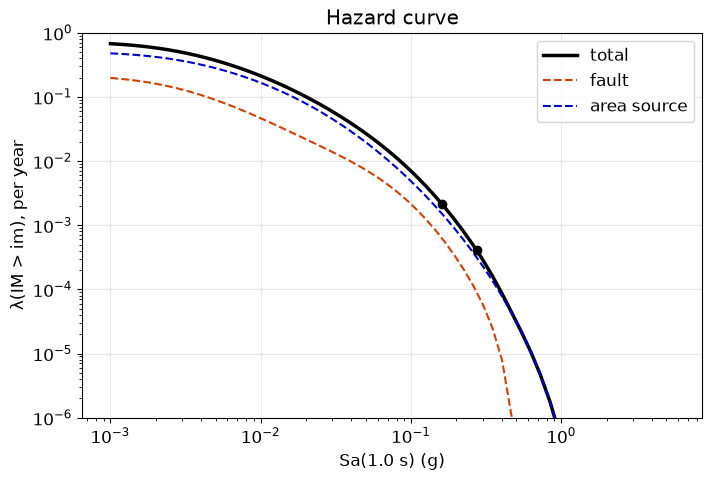

In [10]:
T = 1.0                                     # ✏️ period (s); 0 means PGA
imls = np.logspace(-3, 0.75, 60)
mean, sigma = pt.cy14(T, sc["mag"], sc["rrup"], sc["rjb"], sc["ztor"], P["vs30"])
poe = pt.prob_exceed(imls[:, None], mean[None, :], sigma[None, :])     # P(IM > im | rup_i)
contrib = poe * sc["rate"]                                             # x lambda(rup_i)
lam = contrib.sum(axis=1)                                              # sum over scenarios
lam_fault = contrib[:, sc["source"] == 0].sum(axis=1)

fig, ax = plt.subplots()
ax.loglog(imls, lam, "k", lw=2.5, label="total")
ax.loglog(imls, lam_fault, "--", color=FAULT_C, label="fault")
ax.loglog(imls, lam - lam_fault, "--", color=AREA_C, label="area source")
ax.set(xlabel=f"Sa({T} s) (g)" if T else "PGA (g)", ylabel="λ(IM > im), per year", ylim=(1e-6, 1), title="Hazard curve")

for rp in (475, 2475):                      # ✏️ return periods (years)
    ok = lam > 0                            # (log of zero rates avoided)
    im = np.exp(np.interp(np.log(1 / rp), np.log(lam[ok][::-1]), np.log(imls[ok][::-1])))
    ax.plot(im, 1 / rp, "o", color="k")
    print(f"{rp:>5} yr ({100 * (1 - np.exp(-50 / rp)):.1f} % in 50 years): {im:.3f} g")
ax.legend();

## 7. Uniform hazard spectrum

Read the hazard curve of every period at the same rate $1/RP$ and plot the values against period.
`pt.im_at_rate` does the calculation of section 6 and the interpolation.

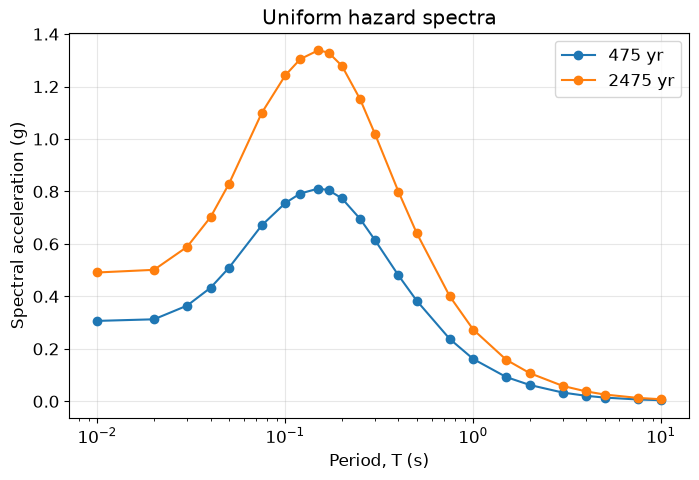

In [11]:
periods = pt.PERIODS[1:]                    # 0.01 to 10 s
fig, ax = plt.subplots()
for rp in (475, 2475):                      # ✏️
    uhs = [pt.im_at_rate(T, 1 / rp, sc) for T in periods]
    ax.semilogx(periods, uhs, "o-", label=f"{rp} yr")
ax.set(xlabel="Period, T (s)", ylabel="Spectral acceleration (g)", title="Uniform hazard spectra")
ax.legend();

## 8. Disaggregation

Which scenarios cause the exceedances? Each scenario's share of the hazard is
$P(rup_i \mid IM > im) = P(IM > im \mid rup_i)\,\lambda(rup_i) / \lambda(IM > im)$, and its
$\varepsilon$ is how many standard deviations above its own median it must be to reach $im$.

mean M 6.43, mean R 26.8 km, mean ε 1.36; fault 29 %


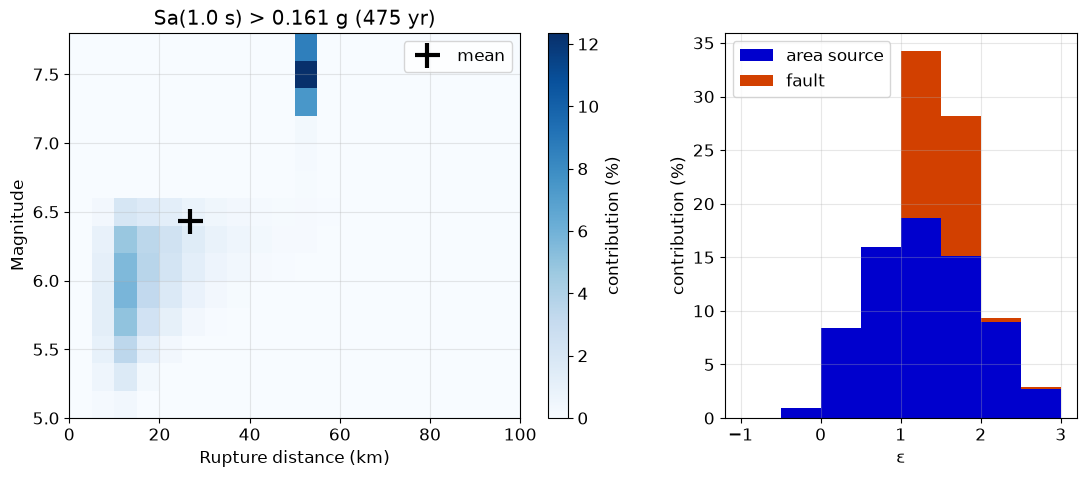

In [12]:
T, rp = 1.0, 475                            # ✏️ try T = 0 (PGA), 3 s; rp = 2475, 10000
im = pt.im_at_rate(T, 1 / rp, sc)
c, eps = pt.disaggregate(T, im, sc)
w = c / c.sum()                             # P(rup_i | IM > im)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.6, 1]})
H, rb, mb = np.histogram2d(sc["rrup"], sc["mag"], bins=[np.arange(0, 105, 5), np.arange(5, 7.81, 0.2)], weights=100 * w)
pc = a1.pcolormesh(rb, mb, H.T, cmap="Blues")
fig.colorbar(pc, ax=a1, label="contribution (%)")
a1.plot(np.sum(w * sc["rrup"]), np.sum(w * sc["mag"]), "k+", ms=18, mew=3, label="mean")
a1.set(xlabel="Rupture distance (km)", ylabel="Magnitude", title=f"{'PGA' if T == 0 else f'Sa({T} s)'} > {im:.3f} g ({rp} yr)")
a1.legend()
eb = np.arange(-1, 3.01, 0.5)
fault = sc["source"] == 0
a2.hist([eps[~fault], eps[fault]], bins=eb, weights=[100 * w[~fault], 100 * w[fault]], stacked=True,
        color=[AREA_C, FAULT_C], label=["area source", "fault"])
a2.set(xlabel="ε", ylabel="contribution (%)")
a2.legend()
print(f"mean M {np.sum(w * sc['mag']):.2f}, mean R {np.sum(w * sc['rrup']):.1f} km, mean ε {np.sum(w * eps):.2f}; "
      f"fault {100 * w[fault].sum():.0f} %")

✏️ *Try*: at 1 s and 475 years the disaggregation is **bimodal**. Is the mean scenario an
earthquake that is likely to happen? How do the modes move with period and with return period?

## 9. Conditional mean spectrum

A record that reaches the uniform hazard level at $T^*$ is not expected to reach it at other periods.
Given $Sa(T^*)$, the expected spectrum (CMS) uses the correlation $\rho(T, T^*)$ of $\varepsilon$
between periods (Baker & Jayaram, 2008):
$\mu_{\ln Sa(T) \mid \ln Sa(T^*)} = \mu_{\ln Sa}(T) + \rho(T, T^*)\,\varepsilon(T^*)\,\sigma_{\ln Sa}(T)$,
computed here scenario by scenario and averaged (Lin et al., 2013).

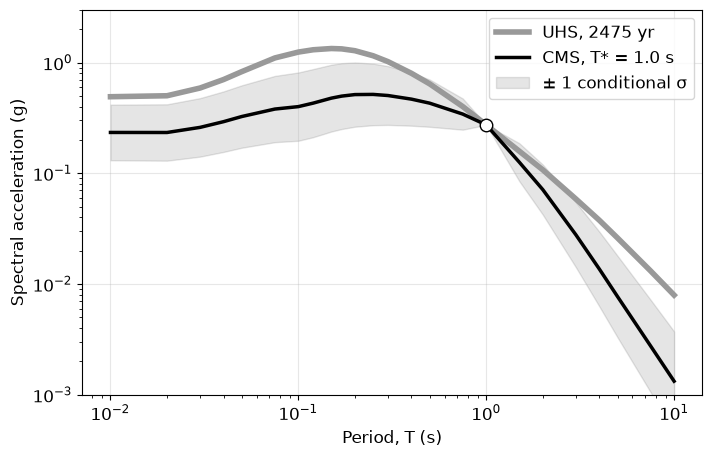

In [13]:
Tstar, rp = 1.0, 2475                       # ✏️ conditioning period and return period
im = pt.im_at_rate(Tstar, 1 / rp, sc)
cms, sd = pt.conditional_spectrum(Tstar, im, sc)
uhs = [pt.im_at_rate(T, 1 / rp, sc) for T in pt.PERIODS]
per = np.maximum(pt.PERIODS, 0.01)
fig, ax = plt.subplots()
ax.loglog(per, uhs, color="0.6", lw=4, label=f"UHS, {rp} yr")
ax.loglog(per, cms, "k", lw=2.5, label=f"CMS, T* = {Tstar} s")
ax.fill_between(per, cms * np.exp(-sd), cms * np.exp(sd), color="k", alpha=0.1, label="± 1 conditional σ")
ax.plot(Tstar, im, "ko", mfc="w", ms=9)
ax.set(xlabel="Period, T (s)", ylabel="Spectral acceleration (g)", ylim=(1e-3, 3))
ax.legend();

## 10. Sensitivity analyses

`design_values` reruns the whole calculation with some parameters changed and returns the design
values. Every change below is relative to the lecture model.

In [14]:
def design_values(rp=475, periods=(0, 0.3, 1, 3), **changes):
    p = dict(pt.PARAMS)
    p.update(changes)
    s = pt.scenarios(p)
    return pd.Series({("PGA" if T == 0 else f"Sa({T} s)"): pt.im_at_rate(T, 1 / rp, s, p) for T in periods})

cases = {                                   # ✏️ add your own: any key of P can be changed
    "lecture model": {},
    "slip rate 15 mm/yr": {"fault_slip_rate": 15},
    "area rate x 2": {"area_rate": 1.0},
    "area radius 150 km": {"area_radius": 150},
    "M_char 7.85": {"fault_mchar": 7.85},
    "truncation 2σ": {"trunc": 2},
    "Vs30 300 m/s": {"vs30": 300},
}
values = pd.DataFrame({name: design_values(**ch) for name, ch in cases.items()})
print("Design values at 475 years (g):")
display(values.round(3))
print("Change relative to the lecture model (%):")
display((100 * (values.div(values["lecture model"], axis=0) - 1)).round(0) + 0.0)

Design values at 475 years (g):


,lecture model,slip rate 15 mm/yr,area rate x 2,area radius 150 km,M_char 7.85,truncation 2σ,Vs30 300 m/s
PGA,0.307,0.304,0.378,0.197,0.306,0.267,0.410
Sa(0.3 s),0.615,0.606,0.766,0.392,0.610,0.523,1.032
Sa(1 s),0.161,0.152,0.195,0.119,0.154,0.142,0.410
Sa(3 s),0.033,0.028,0.037,0.030,0.028,0.031,0.093


Change relative to the lecture model (%):


,lecture model,slip rate 15 mm/yr,area rate x 2,area radius 150 km,M_char 7.85,truncation 2σ,Vs30 300 m/s
PGA,0.0,-1.0,23.0,-36.0,0.0,-13.0,34.0
Sa(0.3 s),0.0,-1.0,25.0,-36.0,-1.0,-15.0,68.0
Sa(1 s),0.0,-6.0,21.0,-26.0,-5.0,-12.0,154.0
Sa(3 s),0.0,-17.0,10.0,-10.0,-17.0,-8.0,178.0


Questions to think about (they are the same as in the PSHA Explorer):

1. Halving the slip rate halves the fault's activity. Why does PGA hardly change, while Sa(3 s) does?
2. Doubling the area source's activity raises PGA by much less than a factor of two. Why?
   (Hint: look at the slope of the hazard curve.)
3. Spreading the same activity over a larger area lowers the hazard. What matters: the total rate,
   or the rate near the site?
4. A larger characteristic magnitude, with the same slip rate, *lowers* the long-period hazard. Why?
5. How much do the design values depend on where the ground-motion distribution is truncated?
   Does it matter more at 475 or at 10,000 years?
6. A softer site amplifies long periods much more than short ones. Why is the amplification
   smaller at longer return periods? (The site term of CY14 is nonlinear.)

## 11. Saving results

Save the hazard curves and a uniform hazard spectrum as CSV files, for a spreadsheet. On Colab they
appear in the *Files* panel on the left (right-click → Download).

In [15]:
imls = np.logspace(-3, 0.75, 60)
curves = pd.DataFrame({("PGA" if T == 0 else f"Sa({T} s)"): pt.hazard_curve(T, imls, sc) for T in (0, 0.3, 1, 3)},
                      index=pd.Index(imls, name="im_g"))
curves.to_csv("hazard_curves.csv")
uhs = pd.DataFrame({"period_s": pt.PERIODS, "sa_475yr_g": [pt.im_at_rate(T, 1 / 475, sc) for T in pt.PERIODS]})
uhs.to_csv("uhs_475yr.csv", index=False)
print("saved hazard_curves.csv and uhs_475yr.csv")

saved hazard_curves.csv and uhs_475yr.csv
